In [1]:
options(scipen=999)
options(width = 10000)
pacman::p_load(dplyr, stringr, data.table, tidyr, plyr, forcats, logr,grid, ggh4x,
               Rmagic, phateR, parallel,gridExtra,ggplot2, ggpubr, ggrepel, ggbreak, gridExtra, patchwork, grid, ggh4x,
               pheatmap, colorRamps, gridExtra, ggplot2, ggrepel, RColorBrewer,ComplexHeatmap,vioplot,ggforce,grid)

In [2]:
# Set working directories
base.dir =  "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/"
assets.dir = paste(base.dir, "Assets/", sep = "") 
results.dir = paste(base.dir, "Results/corrected/", sep = "")
permutation.result.dir = paste(base.dir, "Results/corrected.permutation.test/", sep = "")


# Databases
cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"
Gaulton.db.dir = "/nfs/lab/Luca/Assets/LR.Database/GaultonDB_V2.txt"

permutations.test.tmp.dir = paste(permutation.result.dir, "TMP/", sep = "")
permutations.test.res.dir = paste(permutation.result.dir, "Results/", sep = "")

In [3]:
# Permutation test results:
diff.analysis.dir.ls = c(paste(permutations.test.res.dir, 
                                  "Permutation.test_Aab.Vs.ND_LR.level.interactions.all.columns.res", 
                                 sep = ""), 
                            paste(permutations.test.res.dir, 
                                  "Permutation.test_T1D_early.Vs.ND_LR.level.interactions.all.columns.res",
                                 sep = ""),
                            paste(permutations.test.res.dir, 
                                  "Permutation.test_T1D_late.Vs.ND_LR.level.interactions.all.columns.res",
                                 sep = ""))

# Load SM DBs

In [4]:
# Load and prepare Gaulton DB
Gaulton.db.dir = "/nfs/lab/Luca/Assets/LR.Database/GaultonDB_V2.txt"
# Load list of ligands and receptors
SM.ls.df = read.table(paste(assets.dir, "SM.ls.df.txt", sep=""), sep = "\t", stringsAsFactors = F, header = T)
SM.ls = unique(SM.ls.df$gene)
length(SM.ls)

# Load database
cc.db.data = read.table(cc.db, sep = "\t", stringsAsFactors = F, header = T)
# cc.db.data = cc.db.data[,c(11,2,3)]
message("CCDB number of interactions: ", length(levels(factor(cc.db.data$interaction_name))))

gaulton.db.data = read.table(Gaulton.db.dir, sep = "\t", stringsAsFactors = F, header = T)
colnames(gaulton.db.data)[1] = "gene"

SM.ls.df.GDB = merge(SM.ls.df, gaulton.db.data, by = "gene", all.x = TRUE)
SM.ls.df.GDB[is.na(SM.ls.df.GDB)] <- ""

# Calculate category sizes
categories.size = SM.ls.df.GDB[SM.ls.df.GDB$Type == "Ligand",]

# Ligands
ligands.GDB = filter(SM.ls.df.GDB, Type != "Receptor")
colnames(ligands.GDB)[1] = "ligand"
head(ligands.GDB)

# Make a list of all ligands
ligands.ls = c(unique(cc.db.data$ligand), 
              str_split_fixed(unique(cc.db.data$ligand[grepl("_", cc.db.data$ligand)]), "_", n = 2)[,1],
              str_split_fixed(unique(cc.db.data$ligand[grepl("_", cc.db.data$ligand)]), "_", n = 2)[,2])
ligands.ls = unique(ligands.ls)
ligands.ls = ligands.ls[ligands.ls %in% SM.ls]
# Make a list of all receptors
receptors.ls = c(unique(cc.db.data$receptor),
                 str_split_fixed(unique(cc.db.data$receptor[grepl("_", cc.db.data$receptor)]), "_", n = 2)[,1],
                 str_split_fixed(unique(cc.db.data$receptor[grepl("_", cc.db.data$receptor)]), "_", n = 2)[,2])
receptors.ls = unique(receptors.ls)
receptors.ls = receptors.ls[receptors.ls %in% SM.ls]

# Make a list of all receptors that are also ligands
both = ligands.ls[ligands.ls %in% receptors.ls]
message("Number of ligands that are also receptors: ", length(both))


# Exclude those from the other lists
receptors.ls = receptors.ls[!receptors.ls %in% both]
message("Number of receptors: ", length(receptors.ls))


# Exclude those from the other lists
ligands.ls = ligands.ls[!ligands.ls %in% both]
message("Number of ligands: ", length(ligands.ls))


#Check that the length is 860
message("Final Number of SM: ", length(ligands.ls) + length(receptors.ls) + length(both))

Interaction.type.ls = c("Secreted Signaling", "Cell-Cell Contact", "ECM-Receptor")

Functional.classification.order = c('Hormones & Neuropeptides', 'Enzymes', 'Developmental Proteins', 
                                    'Growth Factors and Cytokines', 'Antigen-Presenting Molecules', 'Complement System',
                                    'Immune regulators', 'Modulators', 'Cell Adhesion Molecule', 'ECM Proteins')

[1] 857

CCDB number of interactions: 1939



,ligand,Type,Mode.of.Action,Functional.classification,Functional.sub.classification,Gene.Family
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ADCYAP1,Ligand,Secreted Signaling,Modulators,Adenylyl Cyclase Modulator,PACAP Family
2,ADGRE5,Ligand,Cell-Cell Contact,Cell Adhesion Molecule,Other Cell Adhesion Proteins,-
3,ADIPOQ,Ligand,Secreted Signaling,Growth Factors and Cytokines,Other Cytokines,Adipokine Family
4,ADM,Ligand,Secreted Signaling,Hormones & Neuropeptides,Hormone (Heart),Adrenomedullin Family
5,AGRN,Ligand,ECM-Receptor,ECM Proteins,Other ECM proteins,Agrin Family
6,AGT,Ligand,Secreted Signaling,Hormones & Neuropeptides,Hormone (Liver),Angiotensinogen Family


Number of ligands that are also receptors: 54

Number of receptors: 379

Number of ligands: 424

Final Number of SM: 857



In [5]:
Functional.classification.order = c('Hormones & Neuropeptides', 'Enzymes', 'Developmental Proteins', 
                                    'Growth Factors and Cytokines', 'Antigen-Presenting Molecules', 'Complement System', 'Immune regulators',
                                    'Modulators', 'Cell Adhesion Molecule', 'ECM Proteins')

# Define cellular compartments

In [6]:
# conditions
condition.ls = c("ND", "Aab", "T1D_early","T1D_late")

colors.conditions = c("ND" = "#85EF1B",
                      "Aab" = "#EFEF1B",
                      "T1D_early" = "#EF851B",
                      "T1D_late" = "#EF1B1B")

# Contrasts
Contrast_1 = c(condition.ls[2], condition.ls[3], condition.ls[4])
Contrast_2 = c(condition.ls[1], condition.ls[1], condition.ls[1])

# Celltypes and compartments
Endocrine = c('Alpha', 'Beta', 'Delta')
Exocrine = c('Acinar1_2_6','Acinar_3','Acinar_4','Acinar_5','Ductal','MUC5b_Ductal')
Immune = c('Tcells','Macrophage')
Endothelial = c('Endothelial')
Stromal = c('Activated_Stellate','Quiescent_Stellate')

cell.pop.order = c(Endocrine, Exocrine, Immune, Endothelial, Stromal)
rev.cell.pop.order = c(rev(Stromal), rev(Endothelial), rev(Immune), rev(Exocrine), rev(Endocrine), use.names = TRUE)

compartment = cell.pop.order
compartment = ifelse(compartment  %in%  Endocrine, "Endocrine", 
                 ifelse(compartment  %in%  Exocrine, "Exocrine",
                        ifelse(compartment  %in%  Immune, "Immune",
                               ifelse(compartment  %in%  Endothelial, "Endothelial", "Stromal"))))

Cellpop.compartment = as.data.frame(cbind(cell.pop.order, compartment))
Cellpop.compartment$compartment = factor(Cellpop.compartment$compartment, levels = c('Endocrine','Exocrine','Immune','Endothelial', "Stromal"))
colnames(Cellpop.compartment)[1] = "Celltype"

colors.compartments = c('Endocrine'='#26bfbf',
           'Exocrine'='#ed872d',
           'Immune'='#3F98E0',
           'Endothelial'='#800080',
           'Stromal'='#F5DE6C')

Cellpop.compartment$colors.compartments = compartment
Cellpop.compartment$colors.compartments = mapvalues(Cellpop.compartment$colors.compartments, names(colors.compartments), colors.compartments, warn_missing = TRUE)
gaps.compartments = c(3, 9, 11, 12)

# Permutation test

In [7]:
LR.data.consensus.sig.thresh = read.table(paste(results.dir,
                                               "LR.data.consensus.sig.thresh.txt", sep = ""),
                                          sep = "\t", stringsAsFactors = F, header = T)
LR.data.consensus.sig.thresh = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$target %in% cell.pop.order, ]
LR.data.consensus.sig.thresh = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$source %in% cell.pop.order, ]

In [8]:
filter(LR.data.consensus.sig.thresh, interaction.id == "Acinar_3--Activated_Stellate--PRSS1--F2RL2") %>% 
      select(interaction.id, condition, prob)

,interaction.id,condition,prob
,<chr>,<chr>,<dbl>
64382,Acinar_3--Activated_Stellate--PRSS1--F2RL2,Aab,0.000166088


In [9]:
# Split data to save FDR and prob 
obs.data.stats.ls = list()

## Create ID column
LR.data.stats = LR.data.consensus.sig.thresh
# Keep only interaction ID, condition, FDR and Prob
LR.data.stats = LR.data.stats[,c(14, 12, 13, 5)]


message("Splitting conditions")
for (i in seq_along(condition.ls)){
    gc(reset = TRUE)
    condition.use = condition.ls[i]
    print(condition.use)
    obs.data.stats.ls[[i]] = LR.data.stats[LR.data.stats$condition == condition.use, ]
}

Splitting conditions



[1] "ND"
[1] "Aab"
[1] "T1D_early"
[1] "T1D_late"


## Observed value

In [10]:
diff.obs = vector(mode = "list", length = length(Contrast_1))
abs.diff.obs = vector(mode = "list", length = length(Contrast_1))
interaction.id.ls = vector(mode = "list", length = length(Contrast_1))

for (i in seq_along(Contrast_1)){
    LR.data.use <- LR.data.consensus.sig.thresh
    message("Detected: ", nrow(LR.data.use), " significant interactions ")
    # Subset for the contrast
    message("Processing ", Contrast_1[i], " vs ", Contrast_2[i])
    contrast = c(Contrast_1[i], Contrast_2[i])
    # make a table of Interaction ID for the contrast (to gather all interactions)
    LR.data.use = LR.data.use[LR.data.use$condition %in% contrast, ]
    message("\t - Detected: ", nrow(LR.data.use), " overall significant interactions in 2 contrasts")
    # Split the dataset
    LR.data.c1 = LR.data.use[LR.data.use$condition %in% contrast[1], ]
    LR.data.c2 = LR.data.use[LR.data.use$condition %in% contrast[2], ]
    message("\t - Distribution of interactions: \n\t   - ",
            Contrast_1[i], ": ", nrow(LR.data.c1), "\n\t   - ",
            Contrast_2[i], ": ", nrow(LR.data.c2))
    # Merge the dataset to have a list of common and unique interactions
    interaction.id.ls[[i]] = merge(LR.data.c1, LR.data.c2, by = "interaction.id", all = TRUE)
    interaction.id.ls[[i]] = as.data.frame(interaction.id.ls[[i]]$interaction.id)
    colnames(interaction.id.ls[[i]]) = "interaction.id"
    message("\t - Detected: ", nrow(interaction.id.ls[[i]]), " unique interactions")
    # Complete data frame to always have all data
    LR.data.c1 = merge(LR.data.c1, interaction.id.ls[[i]], by = "interaction.id", all.y = TRUE)
    LR.data.c2 = merge(LR.data.c2, interaction.id.ls[[i]], by = "interaction.id", all.y = TRUE)
    message("\t - Check that contrasts have same number of interactions: \n\t   - ",
            Contrast_1[i], ": ", nrow(LR.data.c1), "\n\t   - ",
            Contrast_2[i], ": ", nrow(LR.data.c2))
    # Replace NA with 0
    LR.data.c1$prob[is.na(LR.data.c1$prob)] = 0
    LR.data.c2$prob[is.na(LR.data.c2$prob)] = 0
    ## Change rownames
    rownames(LR.data.c1) = LR.data.c1$interaction.id
    rownames(LR.data.c2) = LR.data.c2$interaction.id
    ## Re-order
    LR.data.c1 <- LR.data.c1[order(match(rownames(LR.data.c1), interaction.id.ls[[i]]$interaction.id)), , drop = FALSE]
    LR.data.c2 <- LR.data.c2[order(match(rownames(LR.data.c2), interaction.id.ls[[i]]$interaction.id)), , drop = FALSE]  
    # Compute normalized difference and effect size
    diff.obs[[i]] = LR.data.c1$prob - LR.data.c2$prob
    names(diff.obs[[i]]) = interaction.id.ls[[i]]$interaction.id
    abs.diff.obs[[i]] = abs(diff.obs[[i]])
}

Detected: 87650 significant interactions 

Processing Aab vs ND

	 - Detected: 54598 overall significant interactions in 2 contrasts

	 - Distribution of interactions: 
	   - Aab: 27459
	   - ND: 27139

	 - Detected: 31481 unique interactions

	 - Check that contrasts have same number of interactions: 
	   - Aab: 31481
	   - ND: 31481

Detected: 87650 significant interactions 

Processing T1D_early vs ND

	 - Detected: 45318 overall significant interactions in 2 contrasts

	 - Distribution of interactions: 
	   - T1D_early: 18179
	   - ND: 27139

	 - Detected: 29393 unique interactions

	 - Check that contrasts have same number of interactions: 
	   - T1D_early: 29393
	   - ND: 29393

Detected: 87650 significant interactions 

Processing T1D_late vs ND

	 - Detected: 42012 overall significant interactions in 2 contrasts

	 - Distribution of interactions: 
	   - T1D_late: 14873
	   - ND: 27139

	 - Detected: 28644 unique interactions

	 - Check that contrasts have same number of interac

## Compare with simulation

In [56]:
nsim = 100

In [57]:
for (i in seq_along(Contrast_1)){
    setwd(permutations.test.tmp.dir)
    print(paste("Processing ", Contrast_1[i], " vs ", Contrast_2[i], sep =""))
    # Get files
    sim.list <- dir(pattern = "_DFnet.txt")
    diff.sim.data = NULL
    abs.diff.sim.data = NULL
    for (s.i in seq_along(sim.list)){
        message(" - Processing: ", sim.list[s.i])
        # Load simulation data
        LR.data.use <- read.table(sim.list[s.i], sep = "\t", stringsAsFactors = F, header = T)
        # Replace interaction ID with new one
        LR.data.use = LR.data.use[,-1]
        # Subset for the contrast
        contrast = c(Contrast_1[i], Contrast_2[i])
        # make a table of Interaction ID for the contrast (to gather all interactions)
        LR.data.use = LR.data.use[LR.data.use$condition %in% contrast, ]
        message("\t - Detected: ", nrow(LR.data.use), " significant interactions in contrast")
        LR.data.c1 = LR.data.use[LR.data.use$condition %in% contrast[1], ]
        LR.data.c2 = LR.data.use[LR.data.use$condition %in% contrast[2], ]
        message("\t - Distribution of interactions: \n\t   - ",
                Contrast_1[i], ": ", nrow(LR.data.c1), "\n\t   - ",
                Contrast_2[i], ": ", nrow(LR.data.c2))
        message("\t - Detected: ", nrow(interaction.id.ls[[i]]), " unique interactions from the observations")
        # Complete data frame to always have all data
        LR.data.c1 = merge(LR.data.c1, interaction.id.ls[[i]], by = "interaction.id", all.y = TRUE)
        LR.data.c2 = merge(LR.data.c2, interaction.id.ls[[i]], by = "interaction.id", all.y = TRUE)
        message("\t - Check that contrasts have same number of interactions: \n\t   - ",
            Contrast_1[i], ": ", nrow(LR.data.c1), "\n\t   - ",
            Contrast_2[i], ": ", nrow(LR.data.c2))
        # Replace NA with 0
        LR.data.c1$prob[is.na(LR.data.c1$prob)] = 0
        LR.data.c2$prob[is.na(LR.data.c2$prob)] = 0
        ## Change rownames
        rownames(LR.data.c1) = LR.data.c1$interaction.id
        rownames(LR.data.c2) = LR.data.c2$interaction.id
        ## Re-order
        LR.data.c1 <- LR.data.c1[order(match(rownames(LR.data.c1), interaction.id.ls[[i]]$interaction.id)), , drop = FALSE]
        LR.data.c2 <- LR.data.c2[order(match(rownames(LR.data.c2), interaction.id.ls[[i]]$interaction.id)), , drop = FALSE]
        # Compute difference
        diff.sim = LR.data.c1$prob - LR.data.c2$prob
        names(diff.sim) = interaction.id.ls[[i]]$interaction.id
        abs.diff.sim = abs(diff.sim)
        # pile up results
        diff.sim.data = cbind(diff.sim.data, diff.sim)
        colnames(diff.sim.data)[ncol(diff.sim.data)] = s.i
        abs.diff.sim.data = cbind(abs.diff.sim.data, abs.diff.sim)
        colnames(abs.diff.sim.data)[ncol(abs.diff.sim.data)] = s.i
    }
    message("Comparing simulations against observations")
    random.success.table = abs.diff.sim.data > abs.diff.obs[[i]]
    random.success = rowSums(random.success.table == "TRUE", na.rm = TRUE)
    pvalue = random.success/nsim
    pvalue = replace(pvalue, diff.obs[[i]] == 0, 1)    
    check = diff.obs[[i]] == 0
    check = length(check[check==TRUE])
    message("\t - # Of null observed differential interactions (should be 0 for this analysis): ", check)
    # Make dataframe for stars
    stars = pvalue
    stars[pvalue<=0.05]<-"*"
    stars[pvalue<=0.01]<-"**"
    stars[pvalue==0]<-"***"
    stars[pvalue>0.05]<-""
    diff.analysis = data.frame(contrast.pvalue = pvalue)
    diff.analysis$stars = stars
    diff.analysis$contrasts = paste(Contrast_1[i], ".Vs.", Contrast_2[i], sep = "")
    diff.analysis$interaction.id = rownames(diff.analysis)
    diff.analysis$source = str_split_fixed(diff.analysis$interaction.id, "--", 4)[,1]
    diff.analysis$target = str_split_fixed(diff.analysis$interaction.id, "--", 4)[,2]
    diff.analysis$ligand = str_split_fixed(diff.analysis$interaction.id, "--", 4)[,3]
    diff.analysis$receptor = str_split_fixed(diff.analysis$interaction.id, "--", 4)[,4]
        # Load observation references (First dataset of the list is ND, so I have to add the +1)
        contrast.stats.1 = as.data.frame(obs.data.stats.ls[i + 1])
        ## Second contarst is always ND
        contrast.stats.2 = as.data.frame(obs.data.stats.ls[[1]])
        message("\t - Grabbing observed prob and pvalue: \n\t   - ",
                Contrast_1[i], ": ", nrow(contrast.stats.1), "\n\t   - ",
                Contrast_2[i], ": ", nrow(contrast.stats.2))
        # Subset to just interactions in contrast
        contrast.stats.1 = merge(contrast.stats.1, interaction.id.ls[[i]], by = "interaction.id", all.y = TRUE)
        contrast.stats.2 = merge(contrast.stats.2, interaction.id.ls[[i]], by = "interaction.id", all.y = TRUE)
        # Replace NA with condition name
        contrast.stats.1$condition[is.na(contrast.stats.1$condition)] = Contrast_1[i]
        contrast.stats.2$condition[is.na(contrast.stats.2$condition)] = Contrast_2[i]
        ## Change rownames
        message("\t - Post subset for contrast interactions: \n\t   - ",
                Contrast_1[i], ": ", nrow(contrast.stats.1), "\n\t   - ",
                Contrast_2[i], ": ", nrow(contrast.stats.2))
        rownames(contrast.stats.1) = contrast.stats.1$interaction.id
        rownames(contrast.stats.2) = contrast.stats.2$interaction.id
        ## Re-order
        contrast.stats.1 <- contrast.stats.1[order(match(rownames(contrast.stats.1), interaction.id.ls[[i]]$interaction.id)), , drop = FALSE]
        contrast.stats.2 <- contrast.stats.2[order(match(rownames(contrast.stats.2), interaction.id.ls[[i]]$interaction.id)), , drop = FALSE]
        # bind observed statistics
        diff.analysis$obs.contrast1.prob = contrast.stats.1$prob
        diff.analysis$obs.contrast1.FDR = contrast.stats.1$FDR
        diff.analysis$obs.contrast1.condition = contrast.stats.1$condition
        diff.analysis$obs.contrast2.prob = contrast.stats.2$prob
        diff.analysis$obs.contrast2.FDR = contrast.stats.2$FDR
        diff.analysis$obs.contrast2.condition = contrast.stats.2$condition
        diff.analysis$diff.obs = diff.obs[[i]]    
        # Order collumns
        diff.analysis = diff.analysis[,c(4,5,6,7,8,
                                         11,14,3,
                                         10,13,
                                         9,12,15,
                                         1,2)]
    setwd(permutations.test.res.dir)
    file.name = paste("Permutation.test_", Contrast_1[i], ".Vs.", Contrast_2[i], "_LR.level.interactions.all.columns.res", sep = "")
    write.table(diff.analysis, file.name, sep = "\t", quote = F, col.names=T, row.names = F)    
    
    
    
    diff.analysis = diff.analysis[,c(1, 6, 15)]
    colnames(diff.analysis) = c("interaction.id", "condition", "stars")
    file.name = paste("Permutation.test_", Contrast_1[i], ".Vs.", Contrast_2[i], "_LR.level.interactions.res", sep = "")
    write.table(diff.analysis, file.name, sep = "\t", quote = F, col.names=T, row.names = F)  
}

[1] "Processing Aab vs ND"


 - Processing: CellChat_Permutation_n1_DFnet.txt

	 - Detected: 49488 significant interactions in contrast

	 - Distribution of interactions: 
	   - Aab: 27464
	   - ND: 22024

	 - Detected: 31481 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - Aab: 31481
	   - ND: 31481

 - Processing: CellChat_Permutation_n10_DFnet.txt

	 - Detected: 53239 significant interactions in contrast

	 - Distribution of interactions: 
	   - Aab: 25931
	   - ND: 27308

	 - Detected: 31481 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - Aab: 31481
	   - ND: 31481

 - Processing: CellChat_Permutation_n100_DFnet.txt

	 - Detected: 50674 significant interactions in contrast

	 - Distribution of interactions: 
	   - Aab: 23908
	   - ND: 26766

	 - Detected: 31481 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - Aab: 31481
	   - ND: 31

	 - Detected: 31481 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - Aab: 31481
	   - ND: 31481

 - Processing: CellChat_Permutation_n31_DFnet.txt

	 - Detected: 48605 significant interactions in contrast

	 - Distribution of interactions: 
	   - Aab: 23129
	   - ND: 25476

	 - Detected: 31481 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - Aab: 31481
	   - ND: 31481

 - Processing: CellChat_Permutation_n32_DFnet.txt

	 - Detected: 51465 significant interactions in contrast

	 - Distribution of interactions: 
	   - Aab: 26595
	   - ND: 24870

	 - Detected: 31481 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - Aab: 31481
	   - ND: 31481

 - Processing: CellChat_Permutation_n33_DFnet.txt

	 - Detected: 49580 significant interactions in contrast

	 - Distribution of interactions: 
	   - Aab: 21540
	   - ND: 28

 - Processing: CellChat_Permutation_n53_DFnet.txt

	 - Detected: 52021 significant interactions in contrast

	 - Distribution of interactions: 
	   - Aab: 28080
	   - ND: 23941

	 - Detected: 31481 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - Aab: 31481
	   - ND: 31481

 - Processing: CellChat_Permutation_n54_DFnet.txt

	 - Detected: 50989 significant interactions in contrast

	 - Distribution of interactions: 
	   - Aab: 24098
	   - ND: 26891

	 - Detected: 31481 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - Aab: 31481
	   - ND: 31481

 - Processing: CellChat_Permutation_n55_DFnet.txt

	 - Detected: 48471 significant interactions in contrast

	 - Distribution of interactions: 
	   - Aab: 25930
	   - ND: 22541

	 - Detected: 31481 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - Aab: 31481
	   - ND: 31

	 - Detected: 31481 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - Aab: 31481
	   - ND: 31481

 - Processing: CellChat_Permutation_n76_DFnet.txt

	 - Detected: 53264 significant interactions in contrast

	 - Distribution of interactions: 
	   - Aab: 27089
	   - ND: 26175

	 - Detected: 31481 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - Aab: 31481
	   - ND: 31481

 - Processing: CellChat_Permutation_n77_DFnet.txt

	 - Detected: 44976 significant interactions in contrast

	 - Distribution of interactions: 
	   - Aab: 17962
	   - ND: 27014

	 - Detected: 31481 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - Aab: 31481
	   - ND: 31481

 - Processing: CellChat_Permutation_n78_DFnet.txt

	 - Detected: 51834 significant interactions in contrast

	 - Distribution of interactions: 
	   - Aab: 24468
	   - ND: 27

...

[1] "Processing T1D_late vs ND"


 - Processing: CellChat_Permutation_n1_DFnet.txt

	 - Detected: 45531 significant interactions in contrast

	 - Distribution of interactions: 
	   - T1D_late: 23507
	   - ND: 22024

	 - Detected: 28644 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - T1D_late: 28644
	   - ND: 28644

 - Processing: CellChat_Permutation_n10_DFnet.txt

	 - Detected: 50781 significant interactions in contrast

	 - Distribution of interactions: 
	   - T1D_late: 23473
	   - ND: 27308

	 - Detected: 28644 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - T1D_late: 28644
	   - ND: 28644

 - Processing: CellChat_Permutation_n100_DFnet.txt

	 - Detected: 52849 significant interactions in contrast

	 - Distribution of interactions: 
	   - T1D_late: 26083
	   - ND: 26766

	 - Detected: 28644 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   

 - Processing: CellChat_Permutation_n38_DFnet.txt

	 - Detected: 49336 significant interactions in contrast

	 - Distribution of interactions: 
	   - T1D_late: 24800
	   - ND: 24536

	 - Detected: 28644 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - T1D_late: 28644
	   - ND: 28644

 - Processing: CellChat_Permutation_n39_DFnet.txt

	 - Detected: 50141 significant interactions in contrast

	 - Distribution of interactions: 
	   - T1D_late: 24566
	   - ND: 25575

	 - Detected: 28644 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - T1D_late: 28644
	   - ND: 28644

 - Processing: CellChat_Permutation_n4_DFnet.txt

	 - Detected: 50175 significant interactions in contrast

	 - Distribution of interactions: 
	   - T1D_late: 24217
	   - ND: 25958

	 - Detected: 28644 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   -

 - Processing: CellChat_Permutation_n6_DFnet.txt

	 - Detected: 51954 significant interactions in contrast

	 - Distribution of interactions: 
	   - T1D_late: 26336
	   - ND: 25618

	 - Detected: 28644 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - T1D_late: 28644
	   - ND: 28644

 - Processing: CellChat_Permutation_n60_DFnet.txt

	 - Detected: 53193 significant interactions in contrast

	 - Distribution of interactions: 
	   - T1D_late: 28131
	   - ND: 25062

	 - Detected: 28644 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - T1D_late: 28644
	   - ND: 28644

 - Processing: CellChat_Permutation_n61_DFnet.txt

	 - Detected: 50123 significant interactions in contrast

	 - Distribution of interactions: 
	   - T1D_late: 23693
	   - ND: 26430

	 - Detected: 28644 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   -

 - Processing: CellChat_Permutation_n81_DFnet.txt

	 - Detected: 52762 significant interactions in contrast

	 - Distribution of interactions: 
	   - T1D_late: 23410
	   - ND: 29352

	 - Detected: 28644 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - T1D_late: 28644
	   - ND: 28644

 - Processing: CellChat_Permutation_n82_DFnet.txt

	 - Detected: 50652 significant interactions in contrast

	 - Distribution of interactions: 
	   - T1D_late: 23862
	   - ND: 26790

	 - Detected: 28644 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   - T1D_late: 28644
	   - ND: 28644

 - Processing: CellChat_Permutation_n83_DFnet.txt

	 - Detected: 52516 significant interactions in contrast

	 - Distribution of interactions: 
	   - T1D_late: 26277
	   - ND: 26239

	 - Detected: 28644 unique interactions from the observations

	 - Check that contrasts have same number of interactions: 
	   

In [58]:
tail(contrast.stats.1, n = 4)
tail(contrast.stats.2, n = 4)
tail(diff.analysis, n = 4)

,interaction.id,condition,FDR,prob
,<chr>,<chr>,<dbl>,<dbl>
Tcells--Tcells--WNT7A--FZD5_LRP5,Tcells--Tcells--WNT7A--FZD5_LRP5,T1D_late,NA,NA
Tcells--Tcells--WNT7A--FZD5_LRP6,Tcells--Tcells--WNT7A--FZD5_LRP6,T1D_late,NA,NA
Tcells--Tcells--WNT7A--FZD6_LRP5,Tcells--Tcells--WNT7A--FZD6_LRP5,T1D_late,NA,NA
Tcells--Tcells--WNT7A--FZD6_LRP6,Tcells--Tcells--WNT7A--FZD6_LRP6,T1D_late,NA,NA


,interaction.id,condition,FDR,prob
,<chr>,<chr>,<dbl>,<dbl>
Tcells--Tcells--WNT7A--FZD5_LRP5,Tcells--Tcells--WNT7A--FZD5_LRP5,ND,0.000153715,0.00002393793
Tcells--Tcells--WNT7A--FZD5_LRP6,Tcells--Tcells--WNT7A--FZD5_LRP6,ND,0.000153715,0.00002011978
Tcells--Tcells--WNT7A--FZD6_LRP5,Tcells--Tcells--WNT7A--FZD6_LRP5,ND,0.000153715,0.00006142525
Tcells--Tcells--WNT7A--FZD6_LRP6,Tcells--Tcells--WNT7A--FZD6_LRP6,ND,0.000153715,0.00005162811


,interaction.id,condition,stars
,<chr>,<chr>,<chr>
Tcells--Tcells--WNT7A--FZD5_LRP5,Tcells--Tcells--WNT7A--FZD5_LRP5,T1D_late,
Tcells--Tcells--WNT7A--FZD5_LRP6,Tcells--Tcells--WNT7A--FZD5_LRP6,T1D_late,
Tcells--Tcells--WNT7A--FZD6_LRP5,Tcells--Tcells--WNT7A--FZD6_LRP5,T1D_late,
Tcells--Tcells--WNT7A--FZD6_LRP6,Tcells--Tcells--WNT7A--FZD6_LRP6,T1D_late,


# Create Differential analysis consensus

In [23]:
# Pull differential results together
diff.analysis.ls = list()
diff.analysis = NULL

for (i in seq_along(diff.analysis.dir.ls)){
     data.use = read.table(diff.analysis.dir.ls[i], sep = "\t", stringsAsFactors = F, header = T)
     message("Interactions detected in contrast ", levels(factor(data.use$contrasts)), ": ", nrow(data.use))
     # FDR correction
       data.use$contrast.pvalue[data.use$contrast.pvalue == 0] = 0.0001
       data.use$contrast.FDR = p.adjust(data.use$contrast.pvalue, 'BH')

       data.use$stars = data.use$contrast.FDR
       data.use$stars[data.use$contrast.FDR > 0.1]<-""
       data.use$stars[data.use$contrast.FDR < 0.1]<-"*"
       data.use$stars[data.use$contrast.FDR < 0.05]<-"**"
       data.use$stars[data.use$contrast.FDR < 0.01]<-"***"
     diff.analysis = rbind(diff.analysis, data.use)
}
message("Total number of interactions: ", nrow(diff.analysis), " - Check that sum is correct")
# Remove interactions where entire celltpes/condtion are not present
# AAB.cell.blacklist = c("")
ETD.cell.blacklist = c("MUC5b_Ductal")
LTD.cell.blacklist = c("Delta", "Tcells")

diff.analysis <- diff.analysis %>%
  filter(!((target %in% ETD.cell.blacklist | source %in% ETD.cell.blacklist) 
           & obs.contrast1.condition == condition.ls[3]))

diff.analysis <- diff.analysis %>%
  filter(!((target %in% LTD.cell.blacklist | source %in% LTD.cell.blacklist) 
           & obs.contrast1.condition == condition.ls[4]))

message("Interactions post blacklist: ", nrow(diff.analysis))

# Add annotation
diff.analysis = merge(diff.analysis, ligands.GDB, by = "ligand")
# Save
file.name = paste(results.dir, "ALL_Differential_analysis_Consensus.txt", sep = "")
write.table(diff.analysis, file.name, sep = "\t", quote = F, col.names=T, row.names = T)

# Subset to just have differential interactions
diff.analysis.sig = diff.analysis[!diff.analysis$stars == "",]

message("Number of differential interactions (FDR < 0.1): ", nrow(diff.analysis.sig))
message(" - ND vs AAB: ", nrow(diff.analysis.sig[diff.analysis.sig$obs.contrast1.condition == condition.ls[2], ]))
message(" - ND vs ETD: ", nrow(diff.analysis.sig[diff.analysis.sig$obs.contrast1.condition == condition.ls[3], ]))
message(" - ND vs LTD: ", nrow(diff.analysis.sig[diff.analysis.sig$obs.contrast1.condition == condition.ls[4], ]))

Interactions detected in contrast Aab.Vs.ND: 31481

Interactions detected in contrast T1D_early.Vs.ND: 29393

Interactions detected in contrast T1D_late.Vs.ND: 28644

Total number of interactions: 89518 - Check that sum is correct

Interactions post blacklist: 79011

Number of differential interactions (FDR < 0.1): 1701

 - ND vs AAB: 0

 - ND vs ETD: 632

 - ND vs LTD: 1069



In [24]:
# Assign compartments
diff.analysis.sig$compartment.source = diff.analysis.sig$source

diff.analysis.sig$compartment.source = ifelse(diff.analysis.sig$compartment.source %in%  Endocrine, "Endocrine", 
                 ifelse(diff.analysis.sig$compartment.source %in%  Exocrine, "Exocrine",
                        ifelse(diff.analysis.sig$compartment.source %in%  Immune, "Immune",
                               ifelse(diff.analysis.sig$compartment.source %in%  Endothelial, "Endothelial", "Stromal"))))

diff.analysis.sig$compartment.source = factor(diff.analysis.sig$compartment.source, levels = c('Endocrine','Exocrine','Immune','Endothelial', "Stromal"))
diff.analysis.sig = diff.analysis.sig[!is.na(diff.analysis.sig$compartment.source),]

# Assign compartments
diff.analysis.sig$compartment.target = diff.analysis.sig$target

diff.analysis.sig$compartment.target = ifelse(diff.analysis.sig$compartment.target %in%  Endocrine, "Endocrine", 
                 ifelse(diff.analysis.sig$compartment.target %in%  Exocrine, "Exocrine",
                        ifelse(diff.analysis.sig$compartment.target %in%  Immune, "Immune",
                               ifelse(diff.analysis.sig$compartment.target %in%  Endothelial, "Endothelial", "Stromal"))))

diff.analysis.sig$compartment.target = factor(diff.analysis.sig$compartment.target, levels = c('Endocrine','Exocrine','Immune','Endothelial', "Stromal"))
diff.analysis.sig = diff.analysis.sig[!is.na(diff.analysis.sig$compartment.target),]
diff.analysis.sig = diff.analysis.sig[!is.na(diff.analysis.sig$compartment.source),]

In [25]:
nrow(diff.analysis.sig)

[1] 1701

In [26]:
# factorize stuff
diff.analysis.sig$contrasts = factor(diff.analysis.sig$contrasts, levels = c('T1D_late.Vs.ND', 
                                                                             'T1D_early.Vs.ND', 'Aab.Vs.ND'))
diff.analysis.sig$target = factor(diff.analysis.sig$target, levels = cell.pop.order)
diff.analysis.sig$source = factor(diff.analysis.sig$source, levels = cell.pop.order)
diff.analysis.sig$obs.contrast1.condition = factor(diff.analysis.sig$obs.contrast1.condition, levels = c(condition.ls))
diff.analysis.sig$Interaction.type = factor(diff.analysis.sig$Mode.of.Action, levels = c(Interaction.type.ls))
diff.analysis.sig$Interaction.type = factor(diff.analysis.sig$Mode.of.Action, levels = c(Interaction.type.ls))
# diff.analysis.sig$Functional.classification = factor(diff.analysis.sig$Functional.classification, levels = rev(Functional.classification.order))

In [27]:
# take lowest value possible
min = min(min(diff.analysis.sig$obs.contrast1.prob, na.rm = TRUE), min(diff.analysis.sig$obs.contrast2.prob, na.rm = TRUE))
# backup real prob
diff.analysis.sig$obs.contrast1.prob[is.na(diff.analysis.sig$obs.contrast1.prob)] = 0
diff.analysis.sig$obs.contrast2.prob[is.na(diff.analysis.sig$obs.contrast2.prob)] = 0
diff.analysis.sig$obs.contrast1.prob.fc = diff.analysis.sig$obs.contrast1.prob
diff.analysis.sig$obs.contrast2.prob.fc = diff.analysis.sig$obs.contrast2.prob
## Add fold change column
message(" - Min: ", min)
# Add that value as a pseudocount
diff.analysis.sig$obs.contrast1.prob.fc = diff.analysis.sig$obs.contrast1.prob.fc + min
diff.analysis.sig$obs.contrast2.prob.fc = diff.analysis.sig$obs.contrast2.prob.fc + min

 - Min: 0.0000180519157323933



In [28]:
message(" - Min: ", min(diff.analysis.sig$obs.contrast1.prob.fc, na.rm = TRUE))
nrow(diff.analysis.sig)
diff.analysis.sig = diff.analysis.sig[rowSums(is.na(diff.analysis.sig)) != ncol(diff.analysis.sig), ]
nrow(diff.analysis.sig)
diff.analysis.sig$foldchange = log(diff.analysis.sig$obs.contrast1.prob.fc/diff.analysis.sig$obs.contrast2.prob.fc)
# Note up and down-regulated interactions
diff.analysis.sig$direction = diff.analysis.sig$foldchange
diff.analysis.sig$direction = ifelse(diff.analysis.sig$foldchange > 0, "UP", "DOWN")

 - Min: 0.0000180519157323933



[1] 1701

[1] 1701

In [29]:
file.name = paste(results.dir, "Differential_analysis_Consensus.txt", sep = "")
write.table(diff.analysis.sig, file.name, sep = "\t", quote = F, col.names=T, row.names = T)

## Zoom to one celltype

In [30]:
# I want to do a receptor based analysis where I list the differential interaction

In [31]:
cell.pop.order

[1] "Alpha"              "Beta"               "Delta"              "Acinar1_2_6"        "Acinar_3"           "Acinar_4"           "Acinar_5"           "Ductal"             "MUC5b_Ductal"       "Tcells"             "Macrophage"         "Endothelial"        "Activated_Stellate" "Quiescent_Stellate"

In [32]:
#obs.contrast1.prob
#diff.obs

In [33]:
cell.interest = "Beta"
receptors.ls = c("CD44", "ITGAV_ITGB8")
x = 10

In [36]:
mat = dplyr::filter(diff.analysis.sig,
                     target == cell.interest &
                     receptor %in% receptors.ls)
head(mat)

,ligand,interaction.id,source,target,receptor,obs.contrast1.condition,obs.contrast2.condition,contrasts,obs.contrast1.FDR,obs.contrast2.FDR,⋯,Functional.classification,Functional.sub.classification,Gene.Family,compartment.source,compartment.target,Interaction.type,obs.contrast1.prob.fc,obs.contrast2.prob.fc,foldchange,direction
,<chr>,<chr>,<fct>,<fct>,<chr>,<fct>,<chr>,<fct>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>
1,COL1A1,Activated_Stellate--Beta--COL1A1--CD44,Activated_Stellate,Beta,CD44,T1D_late,ND,T1D_late.Vs.ND,0.000153715,0.000153715,⋯,ECM Proteins,Collagens,Collagen Family,Stromal,Endocrine,ECM-Receptor,0.0054049210,0.00130492554,1.421164,UP
2,COL4A5,Quiescent_Stellate--Beta--COL4A5--CD44,Quiescent_Stellate,Beta,CD44,T1D_early,ND,T1D_early.Vs.ND,0.000153715,0.000153715,⋯,ECM Proteins,Collagens,Collagen Family,Stromal,Endocrine,ECM-Receptor,0.0011466126,0.00027382245,1.432087,UP
3,COL6A3,Activated_Stellate--Beta--COL6A3--CD44,Activated_Stellate,Beta,CD44,T1D_late,ND,T1D_late.Vs.ND,0.000153715,0.000153715,⋯,ECM Proteins,Collagens,Collagen Family,Stromal,Endocrine,ECM-Receptor,0.0180262554,0.00538729006,1.207787,UP
4,COL9A1,Quiescent_Stellate--Beta--COL9A1--CD44,Quiescent_Stellate,Beta,CD44,T1D_early,ND,T1D_early.Vs.ND,0.000153715,NA,⋯,ECM Proteins,Collagens,Collagen Family,Stromal,Endocrine,ECM-Receptor,0.0001622807,0.00001805192,2.196075,UP
5,COL9A3,Ductal--Beta--COL9A3--ITGAV_ITGB8,Ductal,Beta,ITGAV_ITGB8,T1D_late,ND,T1D_late.Vs.ND,0.000153715,0.000153715,⋯,ECM Proteins,Collagens,Collagen Family,Exocrine,Endocrine,ECM-Receptor,0.0002808000,0.00009006716,1.137087,UP
6,COL9A3,Ductal--Beta--COL9A3--CD44,Ductal,Beta,CD44,T1D_late,ND,T1D_late.Vs.ND,0.000153715,0.000153715,⋯,ECM Proteins,Collagens,Collagen Family,Exocrine,Endocrine,ECM-Receptor,0.0011862888,0.00015824193,2.014460,UP


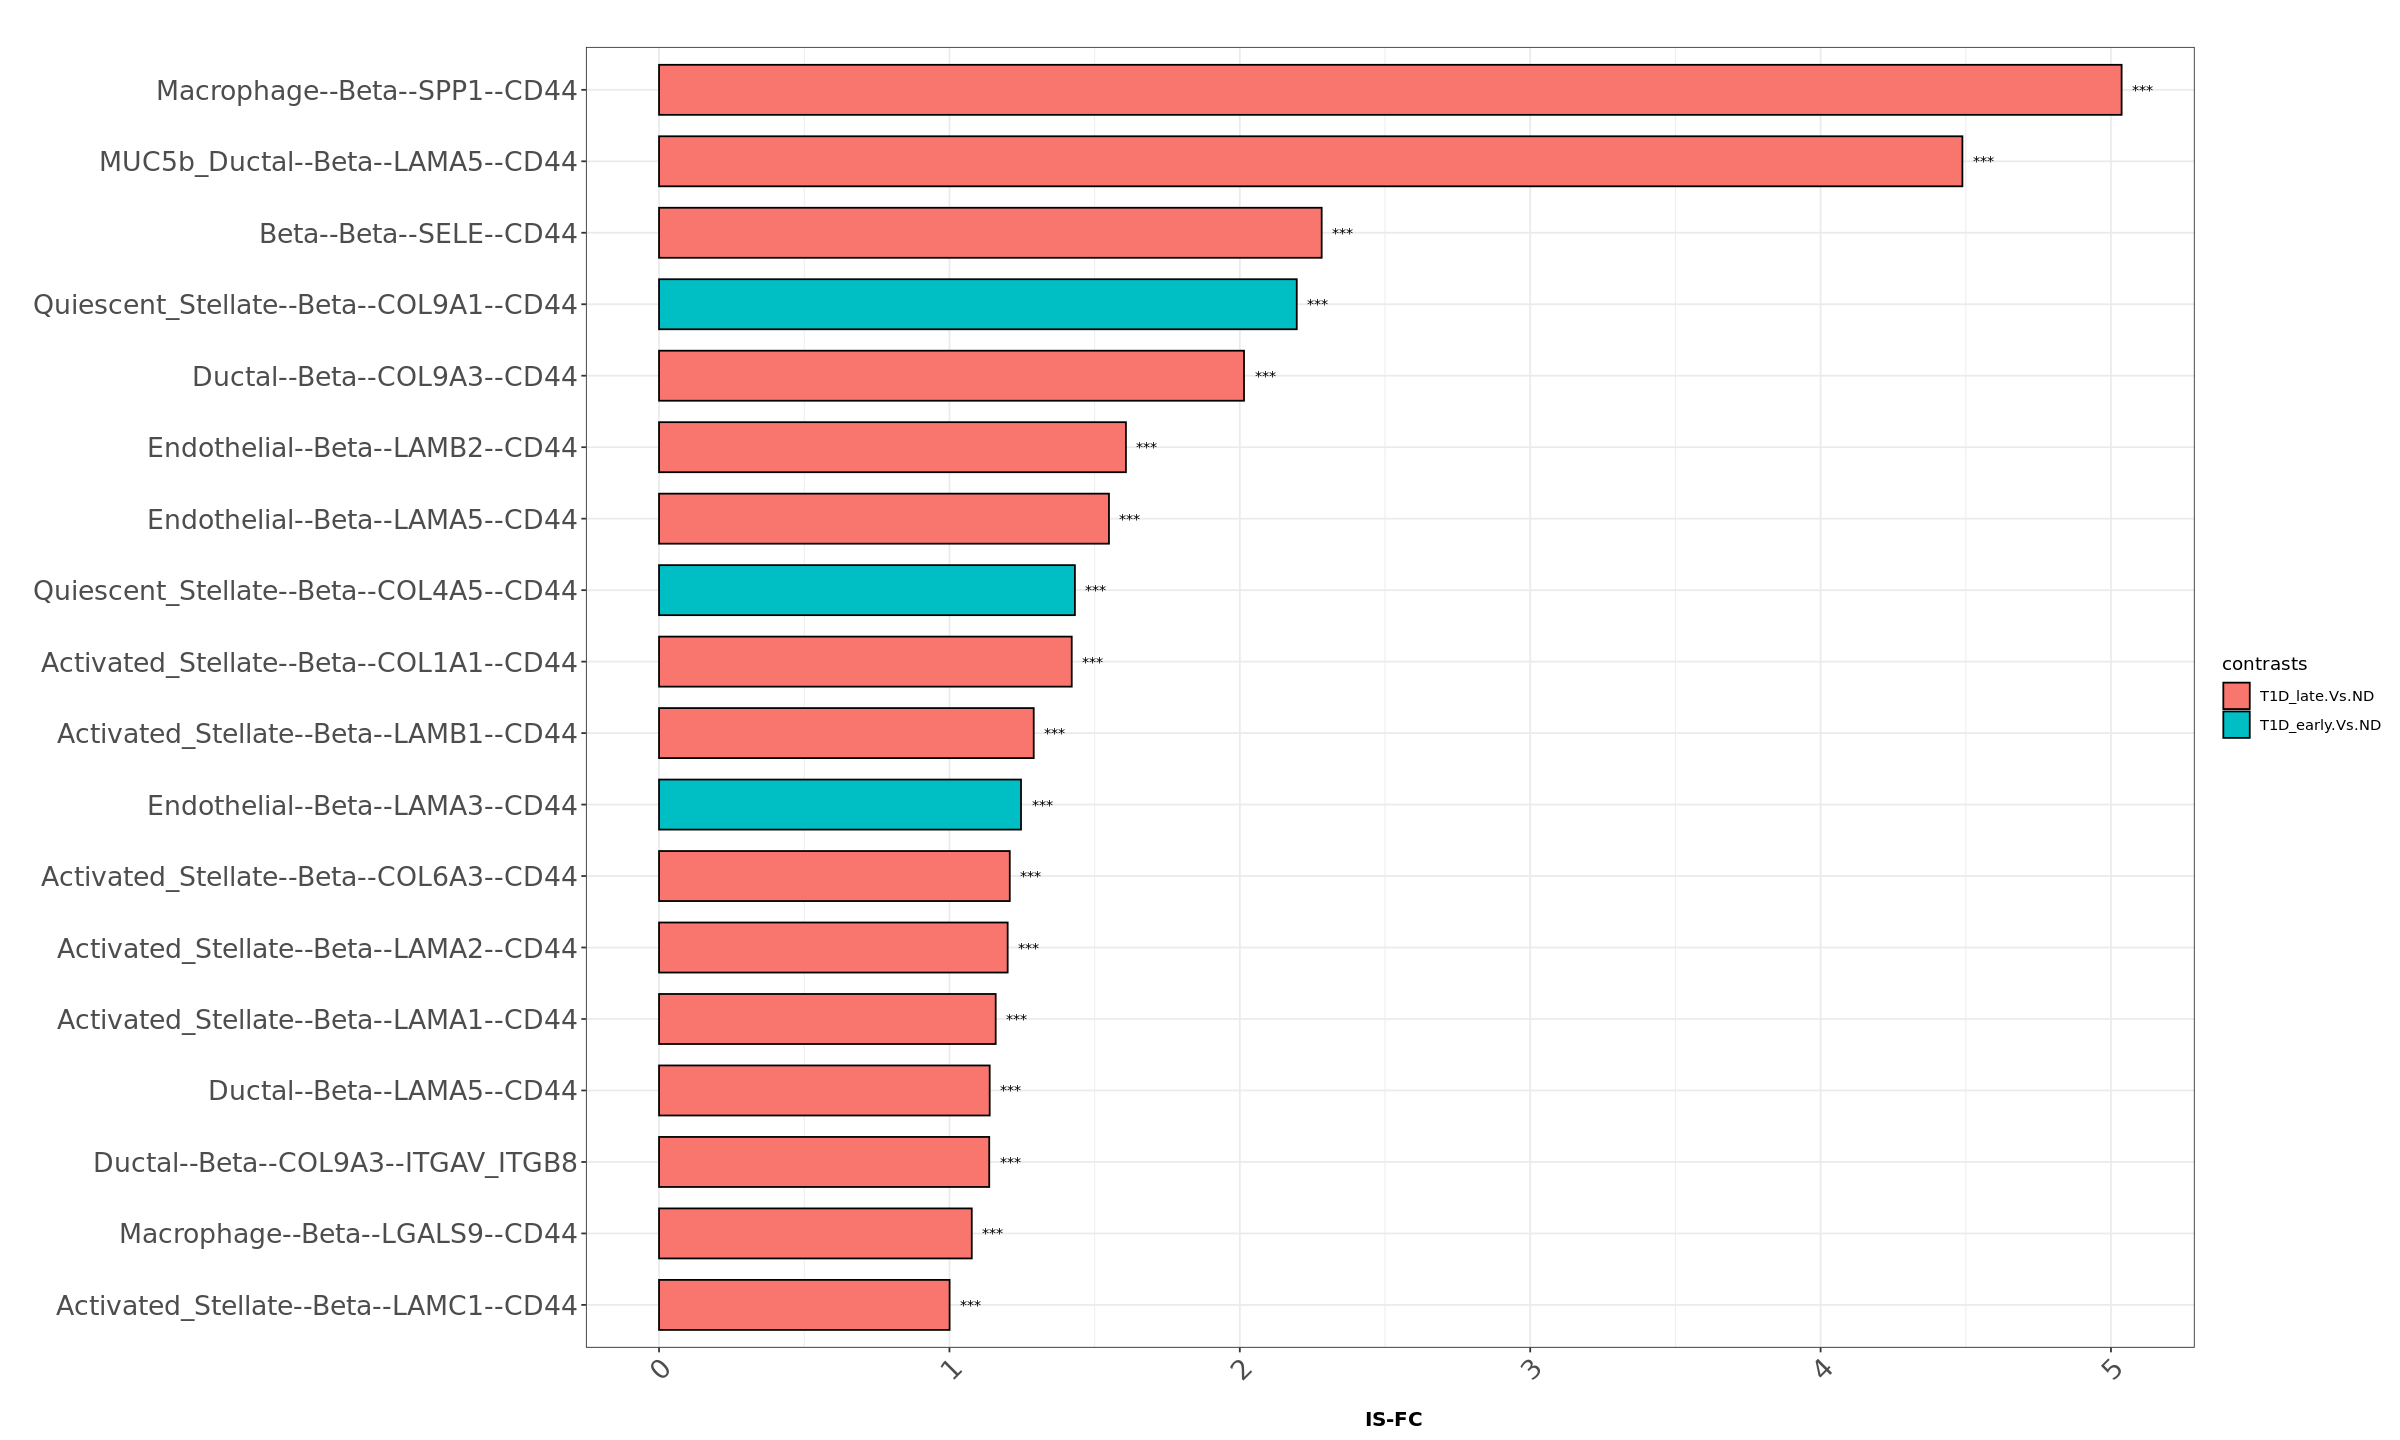

In [46]:
options(repr.plot.width=20, repr.plot.height=12)
ggplot(mat, aes(x = reorder(interaction.id, +foldchange), y = foldchange, fill = contrasts, label = stars)) +
    geom_bar(stat="identity", width = 0.7, colour="black") +
    labs(y= "\n IS-FC", x = "", title = "", position = position_dodge()) +
    theme_bw() +
    theme(axis.text = element_text(size = 16),
          axis.title = element_text(size = 12, face = "bold"), 
          plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "right") + 
   geom_text(hjust = - 0.5, size = 3)+
    coord_flip()

In [52]:
# keep strongest Ligand (don't care about which receptor or source)
# Label top incoming signals (top x)

top <- mat %>%
  dplyr::filter(direction == "UP") %>% 
  dplyr::group_by(contrasts) %>% 
  dplyr::arrange(desc(diff.obs)) %>%
  dplyr::distinct(ligand, .keep_all = TRUE) %>% 
  dplyr::mutate(label = ifelse(row_number() <= x, as.character(ligand), "")) %>%
  dplyr::filter(label != "")%>%
  ungroup()

bottom <- mat %>%
  dplyr::filter(direction == "DOWN") %>% 
  dplyr::group_by(contrasts) %>% 
  dplyr::arrange(diff.obs) %>%
  dplyr::distinct(ligand, .keep_all = TRUE) %>% 
  dplyr::mutate(label = ifelse(row_number() <= x, as.character(ligand), "")) %>%
  dplyr::filter(label != "")%>%
  ungroup()

plot.data = rbind(top, bottom)

plot.data$contrasts = factor(plot.data$contrasts, levels = rev(c('T1D_late.Vs.ND', 
                                                                             'T1D_early.Vs.ND', 'Aab.Vs.ND')))

plot.data.use = dplyr::filter(plot.data, contrasts == 'Aab.Vs.ND')

gg1 = ggplot(plot.data.use, aes(x = reorder(interaction.id, +diff.obs), y = diff.obs, fill = Functional.classification)) +
    geom_bar(stat="identity", width = 0.7, colour="black") +
    labs(y= "\n DELTA - IS", x = "", title = "", position = position_dodge()) +
    theme_bw() +
    theme(axis.text = element_text(size = 16),
          axis.title = element_text(size = 12, face = "bold"), 
          plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "") + 
    coord_flip() +
    facet_nested(cols = vars(contrasts, direction), 
                 scales = "free", space = "fixed")+
  scale_fill_manual(values = color_vector)

plot.data.use = dplyr::filter(plot.data, contrasts == 'T1D_early.Vs.ND')

gg2 = ggplot(plot.data.use, aes(x = reorder(interaction.id, +diff.obs), y = diff.obs, fill = Functional.classification)) +
    geom_bar(stat="identity", width = 0.7, colour="black") +
    labs(y= "\n DELTA - IS", x = "", title = "", position = position_dodge()) +
    theme_bw() +
    theme(axis.text = element_text(size = 16),
          axis.title = element_text(size = 12, face = "bold"), 
          plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "") + 
    coord_flip() +
    facet_nested(cols = vars(contrasts, direction),  
                 scales = "free", space = "fixed")+
  scale_fill_manual(values = color_vector)


plot.data.use = dplyr::filter(plot.data, contrasts == 'T1D_late.Vs.ND')

gg3 = ggplot(plot.data.use, aes(x = reorder(interaction.id, +diff.obs), y = diff.obs, fill = Functional.classification)) +
    geom_bar(stat="identity", width = 0.7, colour="black") +
    labs(y= "\n DELTA - IS", x = "", title = "", position = position_dodge()) +
    theme_bw() +
    theme(axis.text = element_text(size = 16),
          axis.title = element_text(size = 12, face = "bold"), 
          plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "") + 
    coord_flip() +
    facet_nested(cols = vars(contrasts, direction), 
                 scales = "free", space = "fixed")+
  scale_fill_manual(values = color_vector)

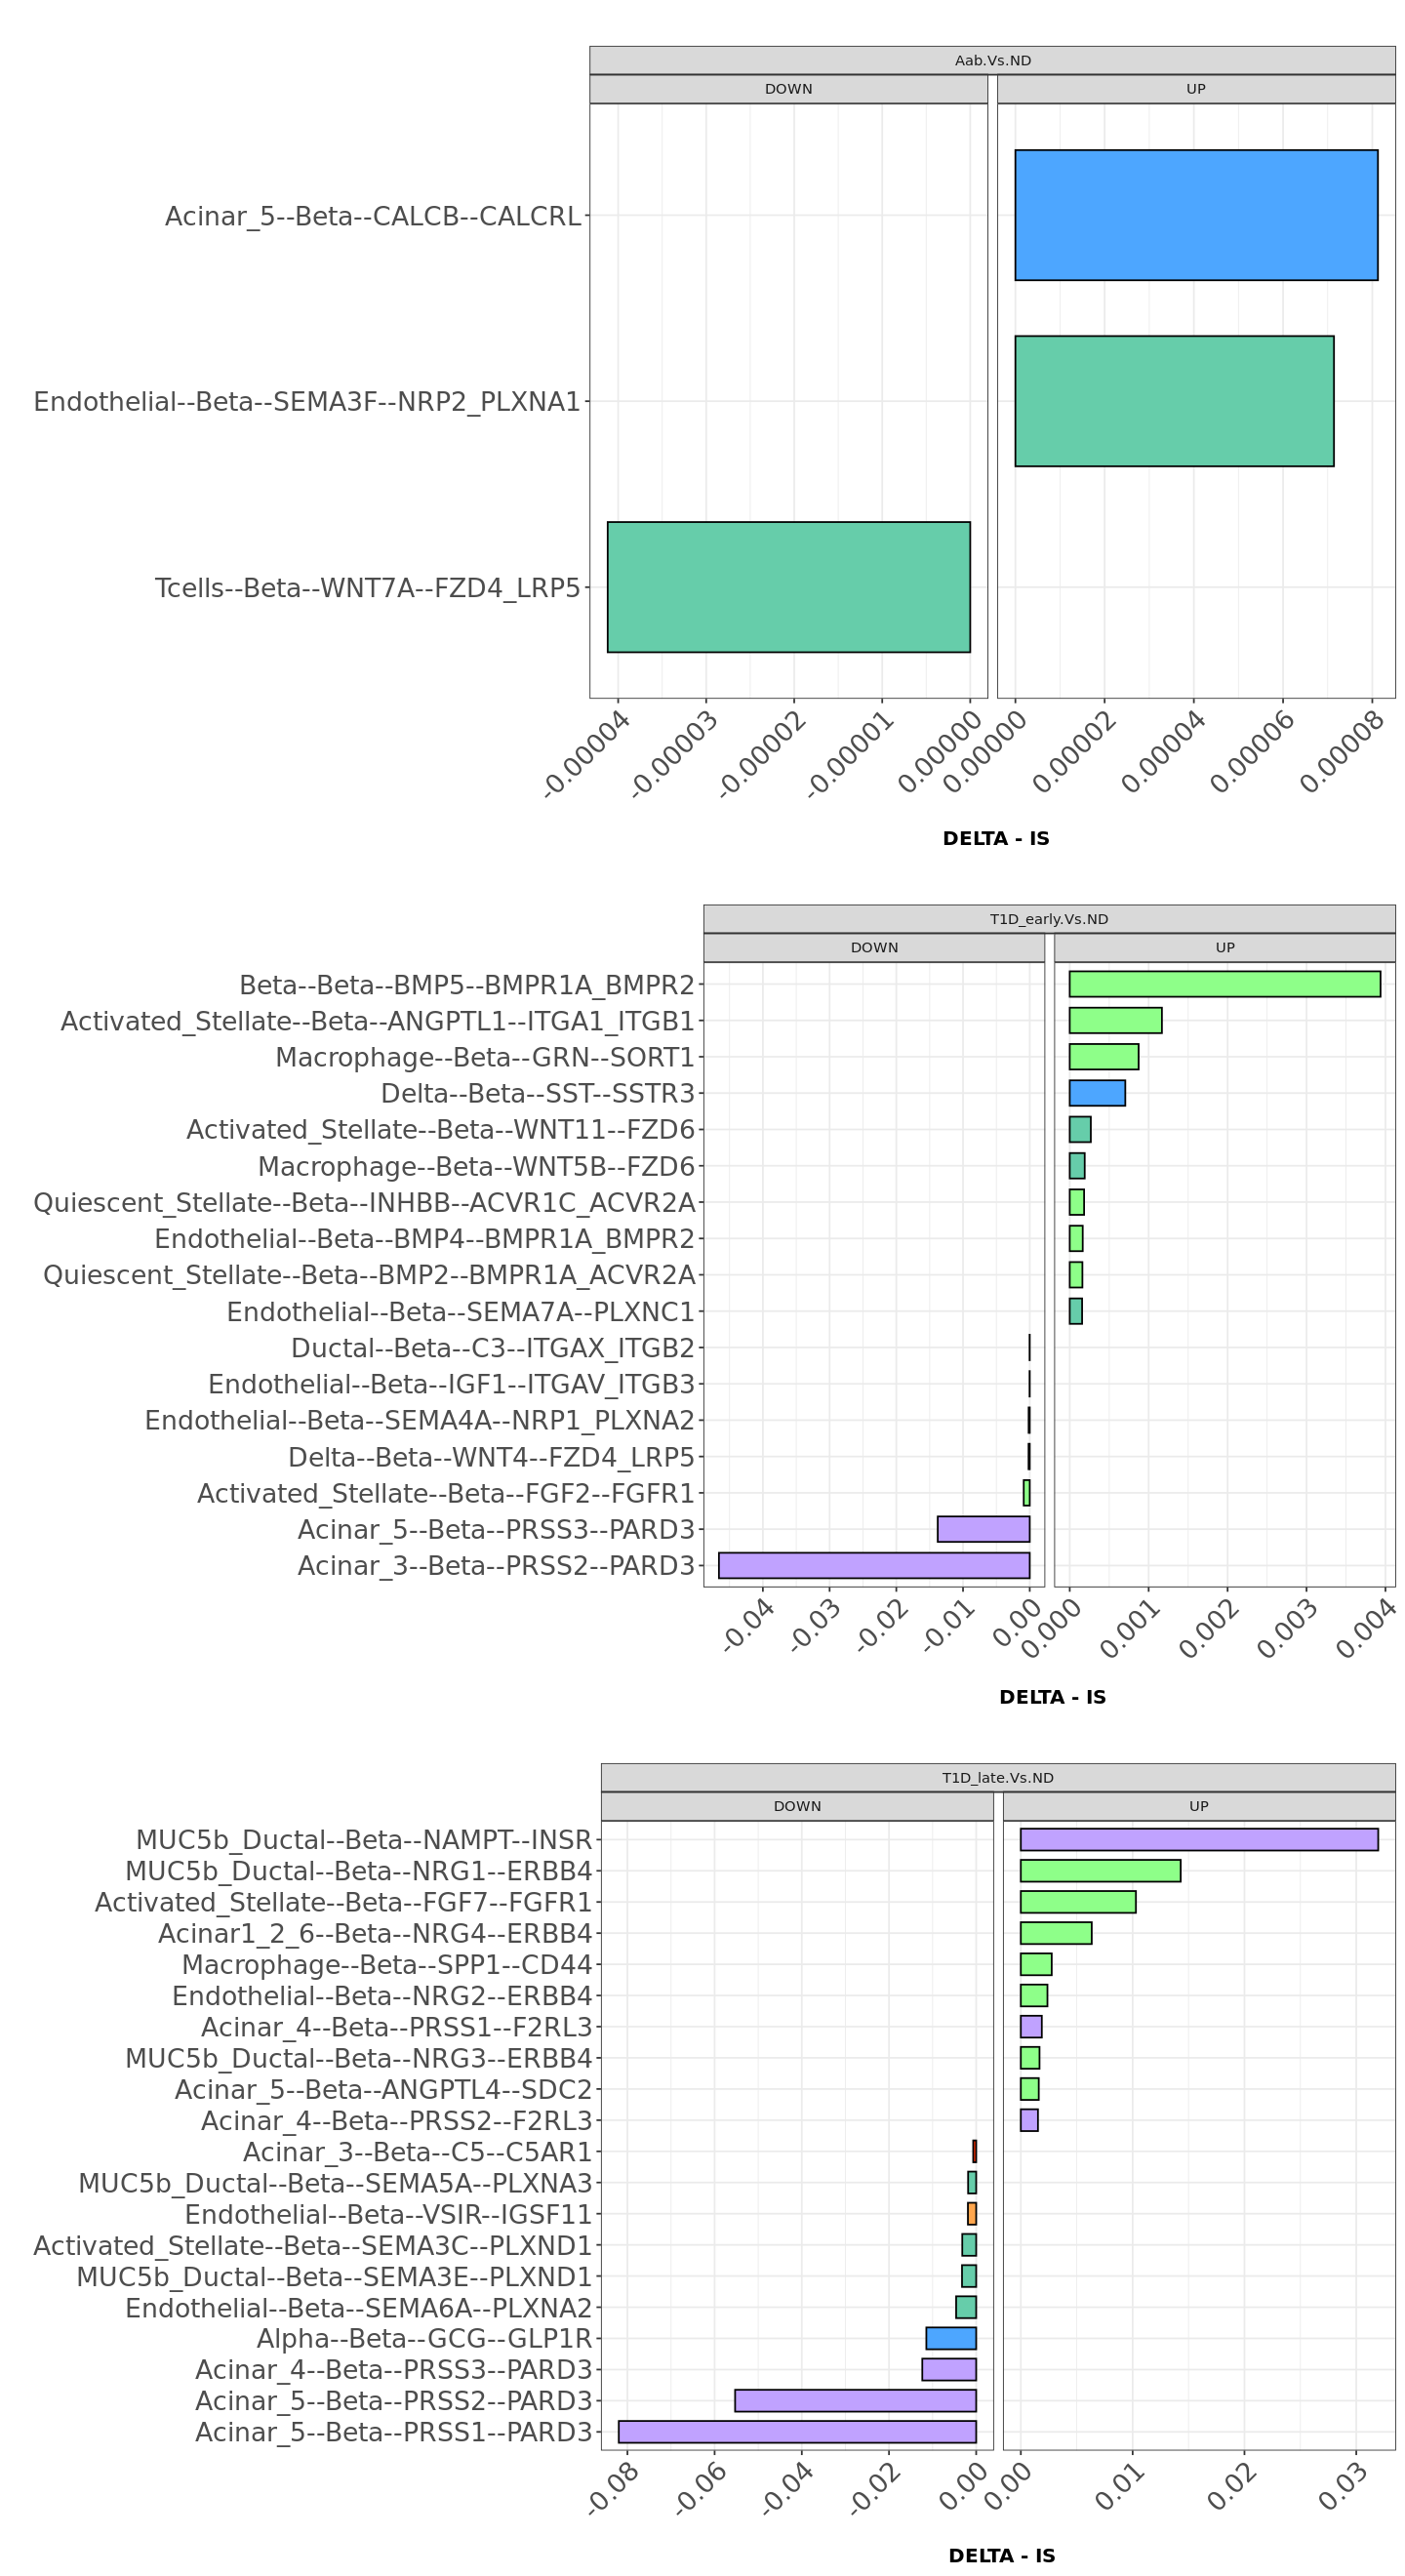

In [53]:
options(repr.plot.width=12, repr.plot.height=22)
grid.arrange(gg1, gg2, gg3, nrow = 3)

In [54]:
mat = filter(diff.analysis.sig.plot,
             source == cell.interest)

In [55]:
## Optional: Subset to remove categories
mat = filter(diff.analysis.sig.plot,
             source == cell.interest,
             Functional.classification != "ECM Proteins" &
             Functional.classification != "Cell Adhesion Molecule" &
             Functional.classification != "Modulators"                         
                        )
nrow(diff.analysis.sig.plot)
nrow(mat)

[1] 6042

[1] 324

In [56]:
# keep strongest Ligand (don't care about which receptor or source)
# Label top incoming signals (top x)

top <- mat %>%
  dplyr::filter(direction == "UP") %>% 
  dplyr::group_by(contrasts) %>% 
  dplyr::arrange(desc(diff.obs)) %>%
  dplyr::distinct(ligand, .keep_all = TRUE) %>% 
  dplyr::mutate(label = ifelse(row_number() <= x, as.character(ligand), "")) %>%
  dplyr::filter(label != "")%>%
  ungroup()

bottom <- mat %>%
  dplyr::filter(direction == "DOWN") %>% 
  dplyr::group_by(contrasts) %>% 
  dplyr::arrange(diff.obs) %>%
  dplyr::distinct(ligand, .keep_all = TRUE) %>% 
  dplyr::mutate(label = ifelse(row_number() <= x, as.character(ligand), "")) %>%
  dplyr::filter(label != "")%>%
  ungroup()

plot.data = rbind(top, bottom)

plot.data$contrasts = factor(plot.data$contrasts, levels = rev(c('T1D_late.Vs.ND', 
                                                                             'T1D_early.Vs.ND', 'Aab.Vs.ND')))

plot.data.use = filter(plot.data, contrasts == 'Aab.Vs.ND')

gg1 = ggplot(plot.data.use, aes(x = reorder(interaction.id, +diff.obs), y = diff.obs, fill = Functional.classification)) +
    geom_bar(stat="identity", width = 0.7, colour="black") +
    labs(y= "\n DELTA - IS", x = "", title = "", position = position_dodge()) +
    theme_bw() +
    theme(axis.text = element_text(size = 16),
          axis.title = element_text(size = 12, face = "bold"), 
          plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "") + 
    coord_flip() +
    facet_nested(cols = vars(contrasts, direction), 
                 scales = "free", space = "fixed")+
  scale_fill_manual(values = color_vector)

plot.data.use = filter(plot.data, contrasts == 'T1D_early.Vs.ND')

gg2 = ggplot(plot.data.use, aes(x = reorder(interaction.id, +diff.obs), y = diff.obs, fill = Functional.classification)) +
    geom_bar(stat="identity", width = 0.7, colour="black") +
    labs(y= "\n DELTA - IS", x = "", title = "", position = position_dodge()) +
    theme_bw() +
    theme(axis.text = element_text(size = 16),
          axis.title = element_text(size = 12, face = "bold"), 
          plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "") + 
    coord_flip() +
    facet_nested(cols = vars(contrasts, direction),  
                 scales = "free", space = "fixed")+
  scale_fill_manual(values = color_vector)


plot.data.use = filter(plot.data, contrasts == 'T1D_late.Vs.ND')

gg3 = ggplot(plot.data.use, aes(x = reorder(interaction.id, +diff.obs), y = diff.obs, fill = Functional.classification)) +
    geom_bar(stat="identity", width = 0.7, colour="black") +
    labs(y= "\n DELTA - IS", x = "", title = "", position = position_dodge()) +
    theme_bw() +
    theme(axis.text = element_text(size = 16),
          axis.title = element_text(size = 12, face = "bold"), 
          plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "") + 
    coord_flip() +
    facet_nested(cols = vars(contrasts, direction), 
                 scales = "free", space = "fixed")+
  scale_fill_manual(values = color_vector)

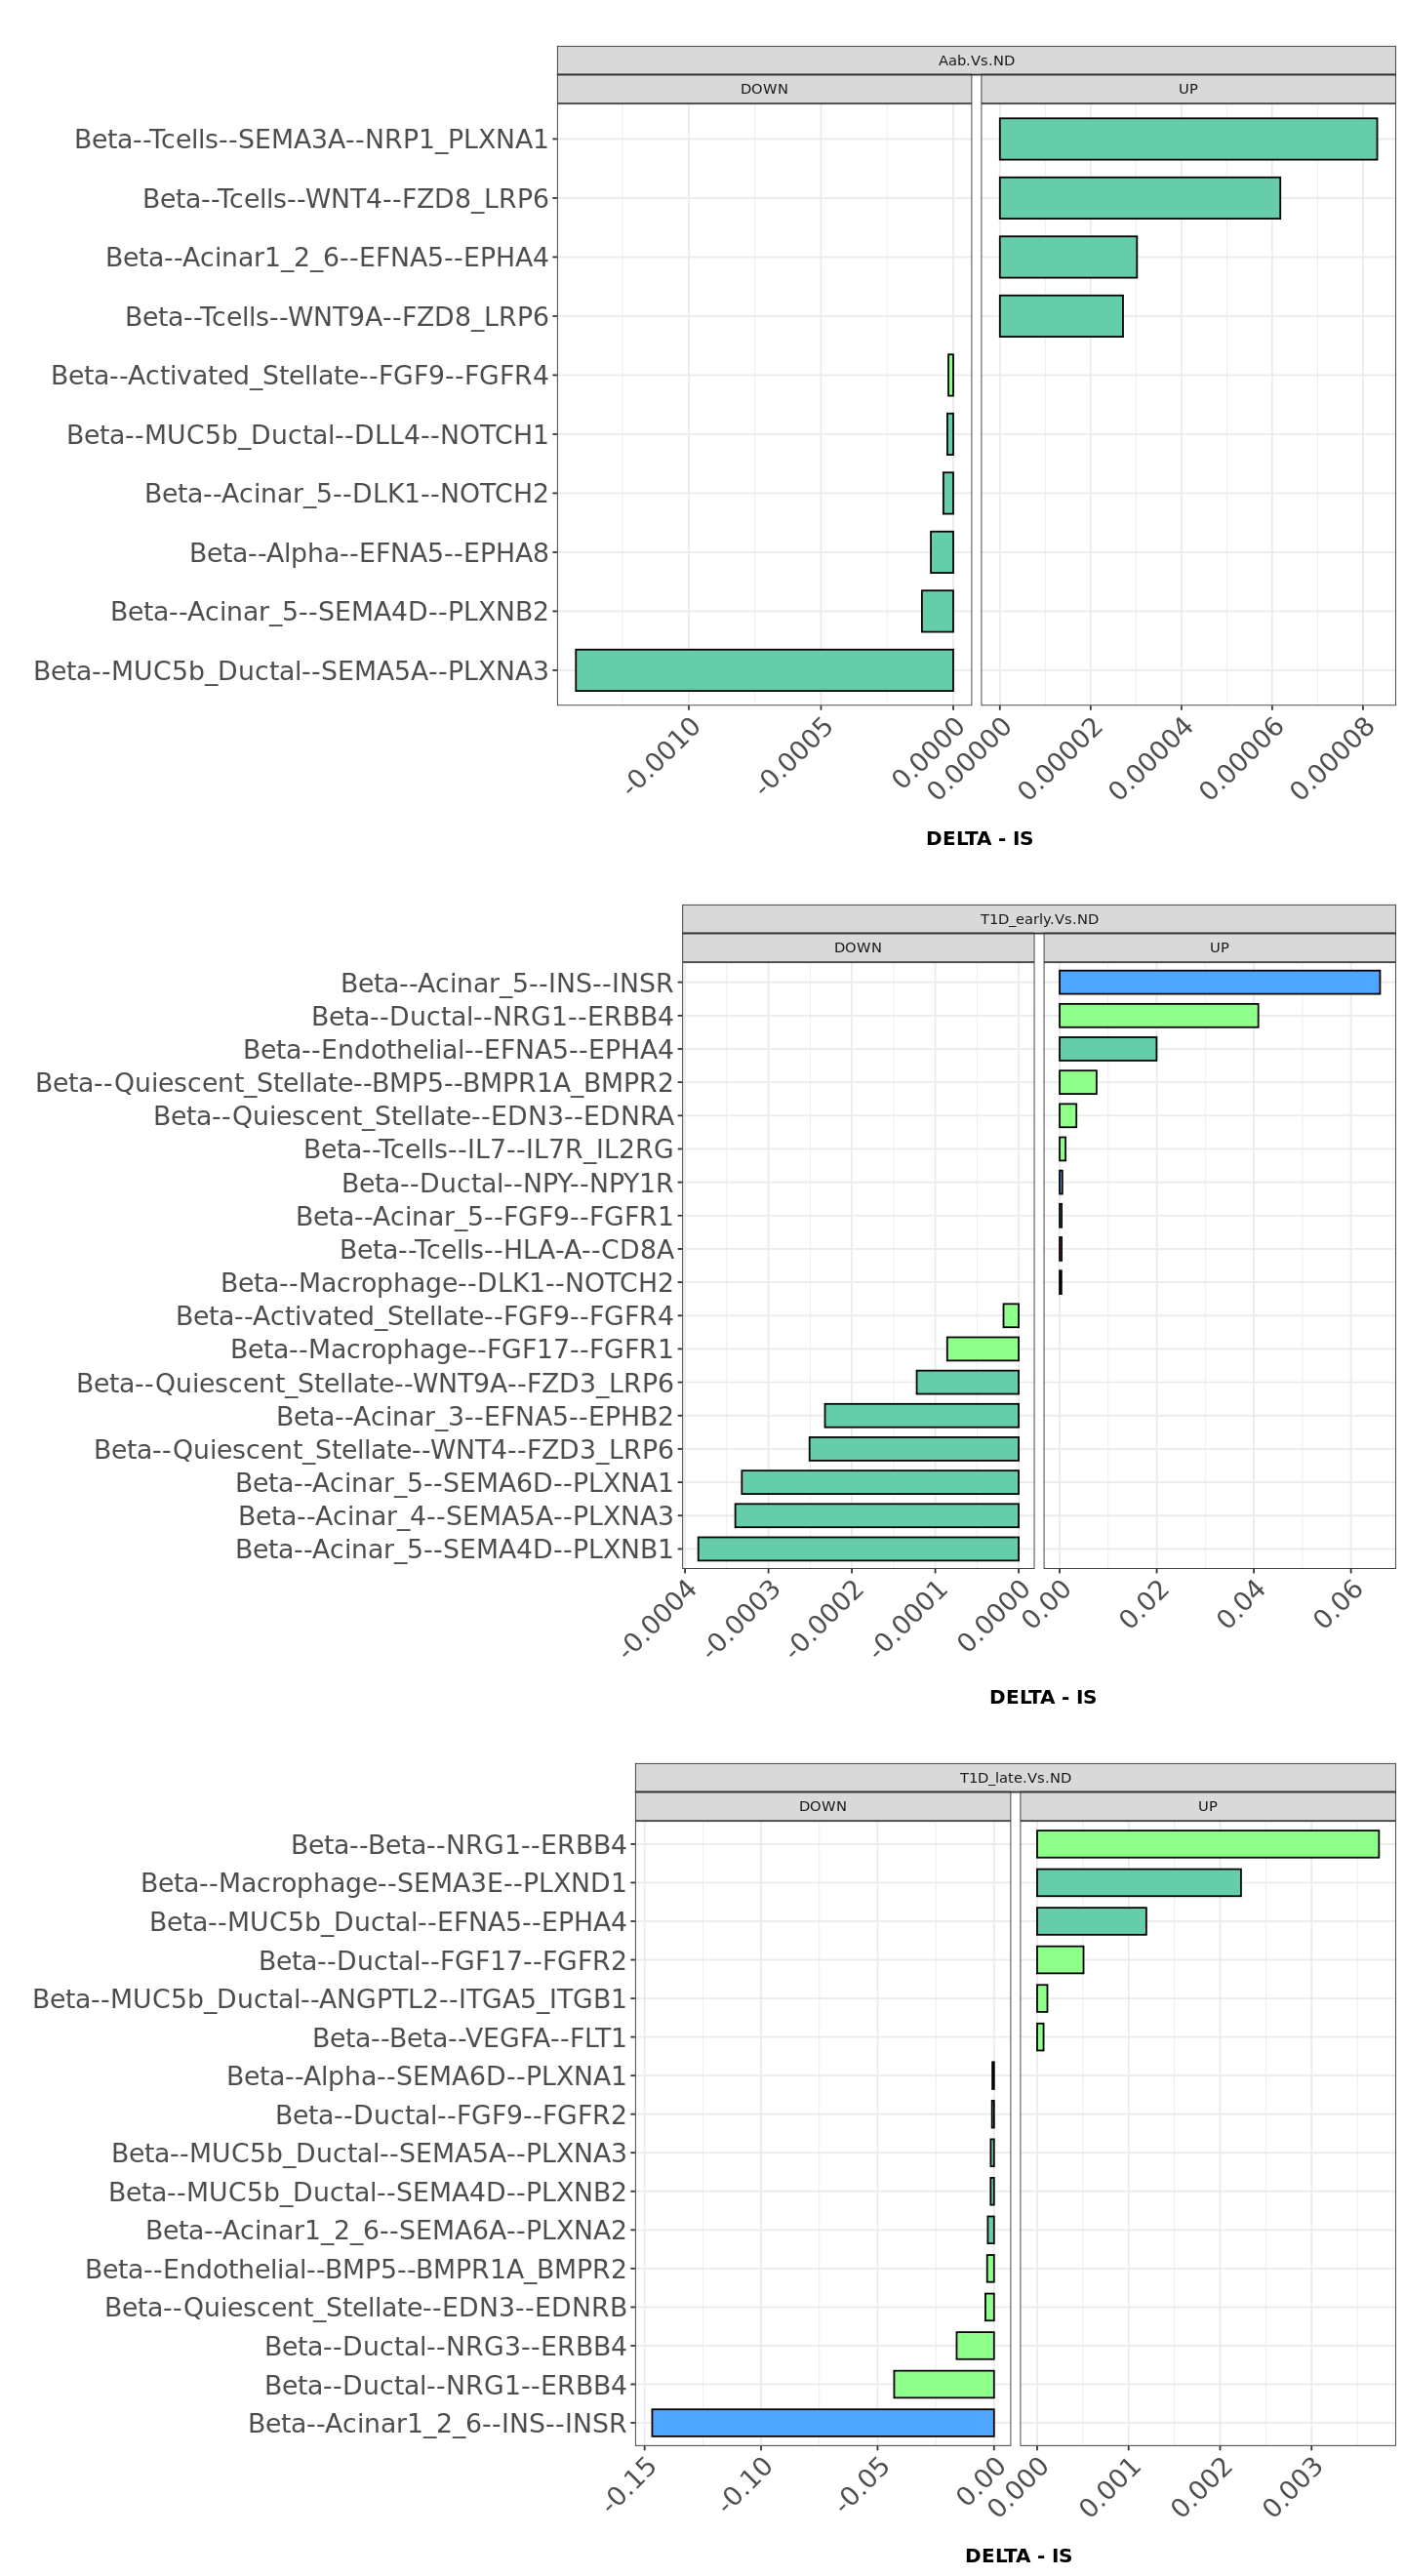

In [57]:
options(repr.plot.width=12, repr.plot.height=22)
grid.arrange(gg1, gg2, gg3, nrow = 3)

In [58]:
# Perform the aggregation
aggregated_data <- aggregate(diff.obs ~ target + ligand + contrasts + direction + Functional.classification, diff.analysis.sig, sum)
colnames(aggregated_data)[1] = "Celltype"
# Add compartment
aggregated_data = merge(Cellpop.compartment, aggregated_data, by = "Celltype")
# factorize stuff
aggregated_data$compartment = factor(aggregated_data$compartment, levels = unique(compartment))
aggregated_data$Celltype = factor(aggregated_data$Celltype, levels = cell.pop.order)
# Make downregulated data become "-"
#aggregated_data$obs.contrast1.prob[aggregated_data$direction == "DOWN"] <- -aggregated_data$obs.contrast1.prob[aggregated_data$direction == "DOWN"]

In [59]:
## Optional: Subset to remove categories
aggregated_data = filter(aggregated_data,
                               Functional.classification != "ECM Proteins" &
                               Functional.classification != "Cell Adhesion Molecule" &
                               Functional.classification != "Modulators"                         
                        )

In [60]:
aggregated_data = filter(aggregated_data, Celltype == cell.interest)
aggregated_data$contrasts = factor(aggregated_data$contrasts, levels = rev(c('T1D_late.Vs.ND', 
                                                                             'T1D_early.Vs.ND', 'Aab.Vs.ND')))

In [61]:
#nrow(aggregated_data)
#aggregated_data = filter(aggregated_data, obs.contrast1.prob != 0)
#nrow(aggregated_data)

In [62]:
# Label top incoming signals (top x)
x = 3

top <- aggregated_data %>%
                    dplyr::group_by(contrasts) %>% 
  dplyr::arrange(desc(obs.contrast1.prob)) %>%
  dplyr::mutate(label = ifelse(row_number() <= x, as.character(ligand), "")) %>%
  dplyr::filter(label != "")%>%
  ungroup()

bottom <- aggregated_data %>%
                    dplyr::group_by(contrasts) %>% 
  dplyr::arrange(obs.contrast1.prob) %>%
  dplyr::mutate(label = ifelse(row_number() <= x, as.character(ligand), "")) %>%
  dplyr::filter(label != "")%>%
  ungroup()

plot.data = rbind(top, bottom)

ERROR: [1m[33mError[39m in `dplyr::arrange()`:[22m
[1m[22m[36mℹ[39m In argument: `..1 = obs.contrast1.prob`.
[1mCaused by error:[22m
[33m![39m object 'obs.contrast1.prob' not found


In [ ]:
# Label top incoming signals (top x)
x = 3

top <- aggregated_data %>%
                    group_by(contrasts) %>% 
  arrange(desc(diff.obs)) %>%
  mutate(label = ifelse(row_number() <= x, as.character(ligand), "")) %>%
  filter(label != "")%>%
  ungroup()

bottom <- aggregated_data %>%
                    group_by(contrasts) %>% 
  arrange(diff.obs) %>%
  mutate(label = ifelse(row_number() <= x, as.character(ligand), "")) %>%
  filter(label != "")%>%
  ungroup()

plot.data = rbind(top, bottom)

In [ ]:
plot.data.use = filter(plot.data, direction == "UP")

gg1 = ggplot(plot.data.use, aes(x = ligand, y = diff.obs, fill = Functional.classification)) +
    geom_bar(stat="identity", width = 0.7, colour="black") +
    labs(y= "\n DELTA - IS", x = "", title = "Incoming Signals", position = position_dodge()) +
    theme_bw() +
    theme(axis.text = element_text(size = 16),
          axis.title = element_text(size = 12, face = "bold"), 
          plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "") + 
    coord_flip() +
    facet_nested(cols = vars(contrasts), 
                 scales = "free", space = "fixed")+
  scale_fill_manual(values = color_vector)

In [ ]:
plot.data.use = filter(plot.data, direction == "DOWN")

gg2 = ggplot(plot.data.use, aes(x = ligand, y = diff.obs, fill = Functional.classification)) +
    geom_bar(stat="identity", width = 0.7, colour="black") +
    labs(y= "\n DELTA - IS", x = "", title = "Incoming Signals", position = position_dodge()) +
    theme_bw() +
    theme(axis.text = element_text(size = 16),
          axis.title = element_text(size = 12, face = "bold"), 
          plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "") + 
    coord_flip() +
    facet_nested(cols = vars(contrasts), 
                 scales = "free", space = "fixed")+
  scale_fill_manual(values = color_vector)

In [ ]:
options(repr.plot.width=12, repr.plot.height=8)
grid.arrange(gg2, gg1, nrow = 1)